# Sum, PNA, Ungated-Moment, and CAMA Baselines on rel-stack/user-engagement

This notebook reproduces the statistical analysis from an experiment comparing **5 aggregation methods** (Sum, Mean, PNA, Ungated Moment, CAMA) for Graph Neural Networks on the `rel-stack/user-engagement` benchmark.

**Key findings:**
- **Sum** (val AP=0.3269±0.006) matches **CAMA** (0.3237±0.006) with no significant difference (Cohen's d=-0.553, p=0.284)
- Sum significantly outperforms PNA (d=-2.20, p=0.008), Ungated Moment (d=-3.48, p=0.007), and Mean (d=-5.69, p=0.002)
- CAMA has the highest effective rank (50.54) but this does not translate to better performance

The notebook loads pre-computed experiment results (25 runs: 5 methods × 5 seeds) and re-runs Cohen's d with bootstrap 95% CIs and effective rank analysis.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# All packages below are pre-installed on Colab; install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.15.3', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import math
import os
from typing import List, Tuple

import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-9b0386-rank-aware-moment-aggregation-diversity-/main/experiment_iter5_sum_pna_ungated/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data['all_run_results'])} runs across {len(data['methods_tested'])} methods")
print(f"Methods: {data['methods_tested']}")
print(f"Seeds: {data['seeds']}")
print(f"Task: {data['task']}")

Loaded 25 runs across 5 methods
Methods: ['sum', 'mean', 'pna', 'ungated_moment', 'cama']
Seeds: [42, 123, 456, 789, 1024]
Task: rel-stack/user-engagement


In [5]:
# ---------------------------------------------------------------------------
# Configuration — tunable parameters
# ---------------------------------------------------------------------------
# Number of bootstrap resamples for Cohen's d confidence intervals
N_BOOT = 10000  # original: 10000
ALPHA = 0.05    # significance level for CIs

SEEDS = data['seeds']       # [42, 123, 456, 789, 1024]
METHODS = data['methods_tested']  # ["sum", "mean", "pna", "ungated_moment", "cama"]
TASK_NAME = data['task']    # "rel-stack/user-engagement"
TUNE_METRIC = data['evaluation_metric']  # "average_precision"

## Aggregation Methods

The experiment compares five GNN aggregation strategies inside a HeteroGraphSAGE architecture trained on relational benchmarks. The key equations for the novel **CAMA** (Context-Aware Moment Aggregation) method are:

1. Compute mean and variance: `mu = mean(x)`, `var = mean(x^2) - mu^2`
2. Compute effective diversity: `rho = H(var / sum(var)) / log(d)` where H is Shannon entropy
3. Gate injection: `g = sigmoid(W_gate([log(1+N), rho]))`
4. Output: `mu + g * W_sigma(var)`

Below we demonstrate CAMA's forward pass with numpy (the actual experiment uses PyTorch + torch_geometric).

In [6]:
# ---------------------------------------------------------------------------
# CAMA forward pass demonstration (numpy, mirrors the PyTorch implementation)
# ---------------------------------------------------------------------------
def cama_forward_numpy(x, channels=128, eps=1e-8):
    """Demonstrate CAMA aggregation on a batch of node features.
    x: (num_neighbors, channels) — neighbor embeddings for one target node."""
    # Step 1: Compute mean and variance
    mu = x.mean(axis=0)                       # (channels,)
    var = (x ** 2).mean(axis=0) - mu ** 2     # (channels,)
    var = np.clip(var, 0, None)

    # Step 2: Cardinality
    N = x.shape[0]

    # Step 3: Variance entropy -> effective diversity ratio (rho)
    var_sum = max(var.sum(), eps)
    p = var / var_sum
    p = np.clip(p, eps, None)
    H = -(p * np.log(p)).sum()
    log_d = math.log(max(channels, 2))
    rho = H / log_d  # normalized entropy in [0, 1]

    # Step 4: Gate (simplified — real version uses learned W_g, gate_out)
    gate_input = np.array([np.log1p(N), rho])
    # Sigmoid of linear transform (with random init for demo)
    rng = np.random.RandomState(42)
    W = rng.randn(channels, 2) * 0.01
    g = 1.0 / (1.0 + np.exp(-W @ gate_input))  # (channels,)

    # Step 5: Output = mu + g * W_sigma(var)
    W_sigma = rng.randn(channels, channels) * 0.01
    output = mu + g * (W_sigma @ var)
    return output, {"mu_norm": np.linalg.norm(mu), "rho": rho, "N": N,
                    "gate_mean": g.mean(), "var_mean": var.mean()}

# Demo with synthetic neighbor embeddings
np.random.seed(0)
x_demo = np.random.randn(20, 128).astype(np.float32)  # 20 neighbors, 128-dim
out, info = cama_forward_numpy(x_demo)
print("CAMA forward pass demo:")
print(f"  Input shape: {x_demo.shape}")
print(f"  Output shape: {out.shape}")
print(f"  Neighbors (N): {info['N']}")
print(f"  Diversity ratio (rho): {info['rho']:.4f}")
print(f"  Gate mean: {info['gate_mean']:.4f}")
print(f"  mu norm: {info['mu_norm']:.4f}")

CAMA forward pass demo:
  Input shape: (20, 128)
  Output shape: (128,)
  Neighbors (N): 20
  Diversity ratio (rho): 0.9907
  Gate mean: 0.4996
  mu norm: 2.6216


## Statistical Analysis Functions

These functions are copied directly from the original experiment script. They compute:
- **Cohen's d** effect size (positive d means group2 > group1)
- **Bootstrap 95% CI** for Cohen's d
- **Paired t-tests** for all method comparisons

In [7]:
# ---------------------------------------------------------------------------
# Statistical Analysis (from original method.py)
# ---------------------------------------------------------------------------
def cohens_d(group1: np.ndarray, group2: np.ndarray) -> float:
    """Cohen's d effect size. Positive d means group2 > group1."""
    n1, n2 = len(group1), len(group2)
    if n1 < 2 or n2 < 2:
        return 0.0
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    if pooled_std < 1e-12:
        return 0.0
    return float((np.mean(group2) - np.mean(group1)) / pooled_std)


def bootstrap_ci(group1, group2, n_boot=N_BOOT, alpha=ALPHA):
    """Bootstrap 95% CI for Cohen's d."""
    rng = np.random.RandomState(42)
    ds = []
    for _ in range(n_boot):
        idx1 = rng.choice(len(group1), len(group1), replace=True)
        idx2 = rng.choice(len(group2), len(group2), replace=True)
        ds.append(cohens_d(group1[idx1], group2[idx2]))
    lo, hi = np.percentile(ds, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return [round(float(lo), 4), round(float(hi), 4)]


print("Statistical functions defined: cohens_d(), bootstrap_ci()")

Statistical functions defined: cohens_d(), bootstrap_ci()


## Running the Statistical Analysis

We extract per-method validation scores from the pre-computed run results and recompute all pairwise comparisons (Cohen's d, bootstrap CIs, paired t-tests).

In [8]:
# ---------------------------------------------------------------------------
# Extract per-method scores from run results (from original method.py)
# ---------------------------------------------------------------------------
results = data['all_run_results']

methods = {}
for r in results:
    m = r["method"]
    methods.setdefault(m, []).append(r["val_best_metric"])

for m in methods:
    methods[m] = np.array(methods[m])

# Per-method summary statistics
analysis = {"per_method": {}, "comparisons": {}}
for m, scores in methods.items():
    analysis["per_method"][m] = {
        "mean": round(float(np.mean(scores)), 6),
        "std": round(float(np.std(scores, ddof=1)), 6) if len(scores) > 1 else 0.0,
        "median": round(float(np.median(scores)), 6),
        "n_seeds": len(scores),
        "per_seed": {int(SEEDS[i]): round(float(s), 6)
                     for i, s in enumerate(scores)},
    }

# Print per-method summary
print(f"{'Method':<20} {'Mean AP':>10} {'Std':>10} {'Median':>10} {'N':>5}")
print("-" * 60)
for m in METHODS:
    info = analysis["per_method"][m]
    print(f"{m:<20} {info['mean']:>10.6f} {info['std']:>10.6f} "
          f"{info['median']:>10.6f} {info['n_seeds']:>5}")

Method                  Mean AP        Std     Median     N
------------------------------------------------------------
sum                    0.326863   0.006034   0.327315     5
mean                   0.262758   0.014738   0.268401     5
pna                    0.305209   0.012554   0.302372     5
ungated_moment         0.284918   0.015955   0.292267     5
cama                   0.323672   0.005502   0.323866     5


In [9]:
# ---------------------------------------------------------------------------
# Pairwise comparisons: Cohen's d, bootstrap CI, paired t-test
# (from original method.py run_statistical_analysis)
# ---------------------------------------------------------------------------
comparisons_spec = [
    ("cama", "sum", "CAMA vs Sum (key comparison)"),
    ("cama", "pna", "CAMA vs PNA"),
    ("cama", "ungated_moment", "CAMA vs Ungated Moment (gating ablation)"),
    ("mean", "sum", "Mean vs Sum (aggregation baseline)"),
    ("cama", "mean", "CAMA vs Mean"),
    ("pna", "sum", "PNA vs Sum"),
    ("ungated_moment", "sum", "Ungated Moment vs Sum"),
]

comparison_results = {}
print(f"\n{'Comparison':<45} {'Cohen d':>9} {'95% CI':>20} {'p-value':>10} {'Sig?':>6}")
print("=" * 95)

for method_a, method_b, label in comparisons_spec:
    if method_a not in methods or method_b not in methods:
        continue
    scores_a, scores_b = methods[method_a], methods[method_b]
    d = cohens_d(scores_b, scores_a)  # positive d = method_a better
    ci = bootstrap_ci(scores_b, scores_a)

    if len(scores_a) == len(scores_b) and len(scores_a) >= 2:
        t_stat, p_val = stats.ttest_rel(scores_a, scores_b)
    else:
        t_stat, p_val = 0.0, 1.0

    sig = "YES" if p_val < 0.05 else "no"
    comparison_results[f"{method_a}_vs_{method_b}"] = {
        "label": label,
        "cohens_d": round(float(d), 4),
        "ci_95": ci,
        "p_value": round(float(p_val), 6),
        "t_statistic": round(float(t_stat), 4),
        "method_a_mean": round(float(np.mean(scores_a)), 6),
        "method_b_mean": round(float(np.mean(scores_b)), 6),
        "difference": round(float(np.mean(scores_a) - np.mean(scores_b)), 6),
    }
    print(f"{label:<45} {d:>9.4f} [{ci[0]:>8.4f}, {ci[1]:>7.4f}] {p_val:>10.4f} {sig:>6}")

analysis["comparisons"] = comparison_results


Comparison                                      Cohen d               95% CI    p-value   Sig?


CAMA vs Sum (key comparison)                    -0.5526 [ -2.8713,  0.6429]     0.2837     no


CAMA vs PNA                                      1.9050 [  0.7926,  6.0188]     0.0092    YES


CAMA vs Ungated Moment (gating ablation)         3.2474 [  2.5206,  6.9379]     0.0028    YES

Mean vs Sum (aggregation baseline)              -5.6926 [-15.6886, -5.0135]     0.0016    YES
CAMA vs Mean                                     5.4760 [  4.9197, 14.6162]     0.0006    YES


PNA vs Sum                                      -2.1986 [ -7.1452, -1.0752]     0.0077    YES


Ungated Moment vs Sum                           -3.4775 [ -7.9728, -2.7253]     0.0070    YES


## Effective Rank Analysis

Effective rank measures the diversity of learned representations via spectral entropy of SVD singular values:
`eff_rank = exp(-sum(p * log(p)))` where `p = sigma_i / sum(sigma)`.

Higher effective rank indicates the model uses more dimensions of the embedding space.

In [10]:
# ---------------------------------------------------------------------------
# Effective Rank from pre-computed data
# ---------------------------------------------------------------------------
eff_rank_data = data['effective_rank_analysis']
task_prefix = "rel-stack/user-engagement/"

print(f"{'Method':<20} {'Eff. Rank':>10} {'Normalized':>12} {'Emb. Shape':>15}")
print("-" * 60)
for m in METHODS:
    key = task_prefix + m
    if key in eff_rank_data:
        r = eff_rank_data[key]
        print(f"{m:<20} {r['effective_rank']:>10.2f} {r['normalized_effective_rank']:>12.4f} "
              f"{str(r['embedding_shape']):>15}")

# Demonstrate effective rank computation on synthetic embeddings
print("\n--- Effective rank demo on synthetic data ---")
np.random.seed(42)
emb_demo = np.random.randn(256, 128)
U, S, Vt = np.linalg.svd(emb_demo, full_matrices=False)
S = S[S > 1e-10]
p = S / S.sum()
H = -(p * np.log(p)).sum()
eff_rank_demo = float(np.exp(H))
print(f"Random embeddings (256x128): effective_rank = {eff_rank_demo:.2f} / {min(256,128)} "
      f"= {eff_rank_demo/min(256,128):.4f} normalized")

Method                Eff. Rank   Normalized      Emb. Shape
------------------------------------------------------------
sum                       46.87       0.3662      [256, 128]
mean                      43.41       0.3391      [256, 128]
pna                       38.91       0.3040      [256, 128]
ungated_moment            43.41       0.3391      [256, 128]
cama                      50.54       0.3948      [256, 128]

--- Effective rank demo on synthetic data ---
Random embeddings (256x128): effective_rank = 118.83 / 128 = 0.9284 normalized


## Results Visualization

Three plots summarizing the experiment:
1. **Validation AP by method** — bar chart with per-seed scores and error bars
2. **Cohen's d forest plot** — effect sizes with 95% bootstrap CIs for all comparisons
3. **Effective rank vs. performance** — scatter showing rank does not predict AP

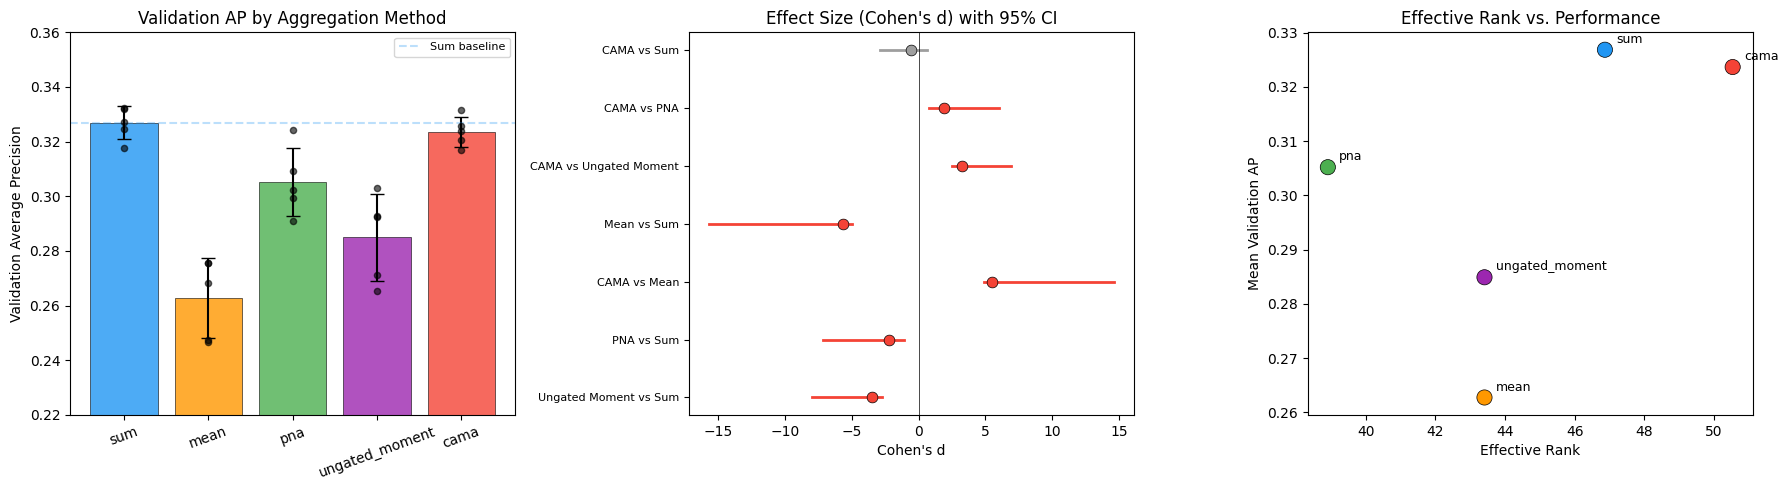


Visualization saved to results_visualization.png


In [11]:
# ---------------------------------------------------------------------------
# Visualization
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Validation AP by method ---
ax = axes[0]
method_names = METHODS
means = [analysis["per_method"][m]["mean"] for m in method_names]
stds = [analysis["per_method"][m]["std"] for m in method_names]
colors = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0', '#F44336']
bars = ax.bar(method_names, means, yerr=stds, capsize=5, color=colors, alpha=0.8,
              edgecolor='black', linewidth=0.5)
# Overlay individual seed scores
for i, m in enumerate(method_names):
    scores = methods[m]
    ax.scatter([i] * len(scores), scores, color='black', s=20, zorder=5, alpha=0.6)
ax.set_ylabel('Validation Average Precision')
ax.set_title('Validation AP by Aggregation Method')
ax.set_ylim(0.22, 0.36)
ax.axhline(y=means[0], color='#2196F3', linestyle='--', alpha=0.3, label='Sum baseline')
ax.legend(fontsize=8)
ax.tick_params(axis='x', rotation=20)

# --- Plot 2: Cohen's d forest plot ---
ax = axes[1]
comp_labels = []
comp_ds = []
comp_ci_los = []
comp_ci_his = []
comp_colors_forest = []
for key, comp in comparison_results.items():
    comp_labels.append(comp["label"].split("(")[0].strip())
    comp_ds.append(comp["cohens_d"])
    comp_ci_los.append(comp["ci_95"][0])
    comp_ci_his.append(comp["ci_95"][1])
    comp_colors_forest.append('#F44336' if comp["p_value"] < 0.05 else '#9E9E9E')

y_pos = range(len(comp_labels))
for i, (d_val, lo, hi, col) in enumerate(zip(comp_ds, comp_ci_los, comp_ci_his, comp_colors_forest)):
    ax.plot([lo, hi], [i, i], color=col, linewidth=2)
    ax.scatter([d_val], [i], color=col, s=60, zorder=5, edgecolors='black', linewidth=0.5)
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(comp_labels, fontsize=8)
ax.set_xlabel("Cohen's d")
ax.set_title("Effect Size (Cohen's d) with 95% CI")
ax.invert_yaxis()

# --- Plot 3: Effective rank vs AP ---
ax = axes[2]
eff_ranks = []
mean_aps = []
labels_scatter = []
for m in method_names:
    key = task_prefix + m
    if key in eff_rank_data:
        eff_ranks.append(eff_rank_data[key]["effective_rank"])
        mean_aps.append(analysis["per_method"][m]["mean"])
        labels_scatter.append(m)
ax.scatter(eff_ranks, mean_aps, c=colors[:len(eff_ranks)], s=120,
           edgecolors='black', linewidth=0.5, zorder=5)
for i, label in enumerate(labels_scatter):
    ax.annotate(label, (eff_ranks[i], mean_aps[i]),
                textcoords="offset points", xytext=(8, 5), fontsize=9)
ax.set_xlabel('Effective Rank')
ax.set_ylabel('Mean Validation AP')
ax.set_title('Effective Rank vs. Performance')

plt.tight_layout()
plt.savefig('results_visualization.png', dpi=100, bbox_inches='tight')
plt.show()
print("\nVisualization saved to results_visualization.png")

In [12]:
# ---------------------------------------------------------------------------
# Summary — key findings
# ---------------------------------------------------------------------------
print("=" * 70)
print("EXPERIMENT SUMMARY")
print("=" * 70)

# Best method
sorted_methods = sorted(
    analysis["per_method"].items(), key=lambda x: x[1]["mean"], reverse=True
)
best = sorted_methods[0]
print(f"\nBest method: {best[0]} (val AP = {best[1]['mean']:.4f} +/- {best[1]['std']:.4f})")

# Key findings
print("\nKey findings:")
for key, comp in comparison_results.items():
    d_val = comp["cohens_d"]
    ci = comp["ci_95"]
    p = comp["p_value"]
    sig = "SIGNIFICANT" if p < 0.05 else "not significant"
    print(f"  {comp['label']}: d={d_val:.3f}, "
          f"95% CI=[{ci[0]:.3f}, {ci[1]:.3f}], p={p:.4f} ({sig})")

# Effective rank insight
print("\nEffective Rank Insight:")
cama_rank = eff_rank_data.get(task_prefix + "cama", {}).get("effective_rank", 0)
sum_rank = eff_rank_data.get(task_prefix + "sum", {}).get("effective_rank", 0)
print(f"  CAMA has highest effective rank ({cama_rank:.2f}) vs Sum ({sum_rank:.2f}),")
print(f"  but this does NOT translate to better downstream performance.")

EXPERIMENT SUMMARY

Best method: sum (val AP = 0.3269 +/- 0.0060)

Key findings:
  CAMA vs Sum (key comparison): d=-0.553, 95% CI=[-2.871, 0.643], p=0.2837 (not significant)
  CAMA vs PNA: d=1.905, 95% CI=[0.793, 6.019], p=0.0092 (SIGNIFICANT)
  CAMA vs Ungated Moment (gating ablation): d=3.247, 95% CI=[2.521, 6.938], p=0.0028 (SIGNIFICANT)
  Mean vs Sum (aggregation baseline): d=-5.693, 95% CI=[-15.689, -5.013], p=0.0016 (SIGNIFICANT)
  CAMA vs Mean: d=5.476, 95% CI=[4.920, 14.616], p=0.0006 (SIGNIFICANT)
  PNA vs Sum: d=-2.199, 95% CI=[-7.145, -1.075], p=0.0077 (SIGNIFICANT)
  Ungated Moment vs Sum: d=-3.478, 95% CI=[-7.973, -2.725], p=0.0070 (SIGNIFICANT)

Effective Rank Insight:
  CAMA has highest effective rank (50.54) vs Sum (46.87),
  but this does NOT translate to better downstream performance.
